Saving Titanic-Dataset.csv to Titanic-Dataset (2).csv
🔹 Shape: (891, 12)

🔹 First 3 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  

🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1  

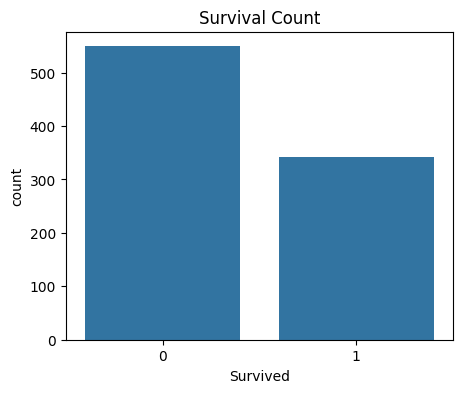

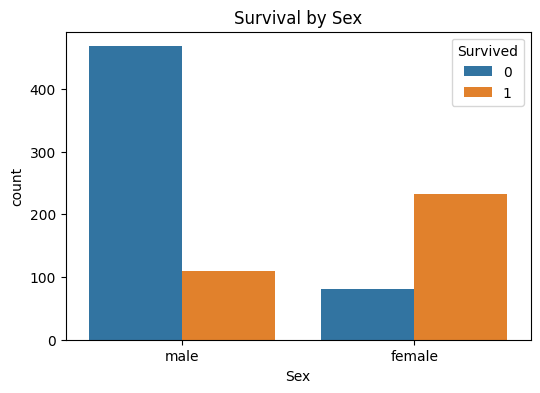

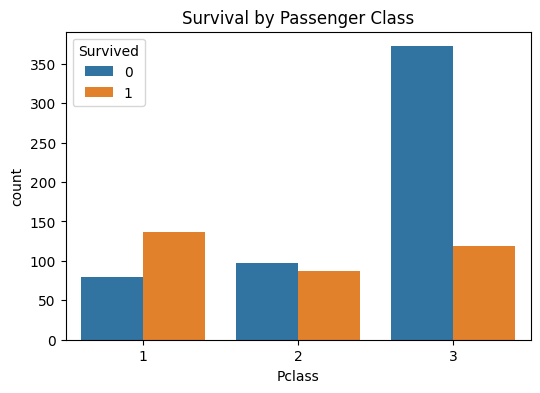

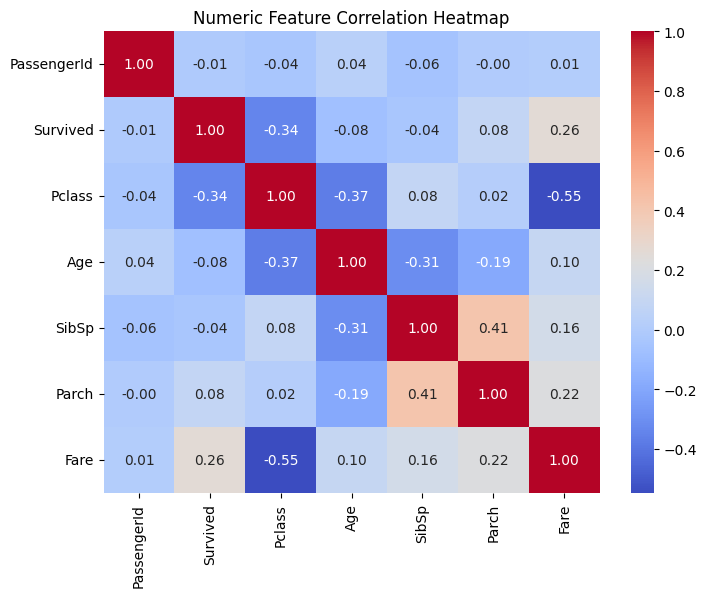

✅ Data ready for modeling.
Train shape: (712, 10) | Test shape: (179, 10)


In [3]:
# 🌟 Exercise 1 : Exploratory Data Analysis (EDA)
# -------------------------------------------------
# Goal: Load Titanic dataset, clean missing values, engineer features,
# and prepare a reusable preprocessing pipeline and train/test split.
# -------------------------------------------------

from google.colab import files
uploaded = files.upload()

# --- Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# --- Load dataset ---
df = pd.read_csv('Titanic-Dataset.csv')

print("🔹 Shape:", df.shape)
print("\n🔹 First 3 rows:")
print(df.head(3))
print("\n🔹 Info:")
print(df.info())
print("\n🔹 Missing values:")
print(df.isnull().sum())

# --- Clean unnecessary columns ---
cols_to_drop = [c for c in ['Ticket'] if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# --- Feature Engineering Function ---
def add_features(frame: pd.DataFrame) -> pd.DataFrame:
    df_ = frame.copy()

    # Extract title from Name
    if 'Name' in df_.columns:
        df_['Title'] = df_['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
        rare = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
        df_['Title'] = df_['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})
        df_['Title'] = df_['Title'].apply(lambda t: 'Rare' if t in rare else t)
    else:
        df_['Title'] = 'Unknown'

    # Family size & isolation
    for c in ['SibSp','Parch']:
        if c not in df_.columns:
            df_[c] = 0
    df_['FamilySize'] = df_['SibSp'] + df_['Parch'] + 1
    df_['IsAlone'] = (df_['FamilySize'] == 1).astype(int)

    # Cabin initial (first letter)
    if 'Cabin' in df_.columns:
        df_['CabinInitial'] = df_['Cabin'].astype(str).str[0].replace('n','U')
    else:
        df_['CabinInitial'] = 'U'

    return df_

# --- Target column ---
target_col = 'Survived'
assert target_col in df.columns, "Target column 'Survived' not found."

# --- Visuals ---
plt.figure(figsize=(5,4))
sns.countplot(data=df, x=target_col)
plt.title("Survival Count")
plt.show()

if 'Sex' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='Sex', hue=target_col)
    plt.title("Survival by Sex")
    plt.show()

if 'Pclass' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='Pclass', hue=target_col)
    plt.title("Survival by Passenger Class")
    plt.show()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) >= 2:
    plt.figure(figsize=(8,6))
    sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Numeric Feature Correlation Heatmap")
    plt.show()

# --- Preprocessing Pipeline ---
numeric_features = ['Age','Fare','SibSp','Parch','FamilySize']
categorical_features = ['Pclass','Sex','Embarked','Title','CabinInitial']

feature_eng = FunctionTransformer(add_features, validate=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ✅ FIX: sparse_output=False instead of sparse=False
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

df_eng_cols = add_features(df).columns
num_exist = [c for c in numeric_features if c in df_eng_cols]
cat_exist = [c for c in categorical_features if c in df_eng_cols]

preprocessor = Pipeline(steps=[
    ('feat_eng', feature_eng),
    ('ct', ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_exist),
            ('cat', categorical_transformer, cat_exist)
        ],
        remainder='drop'
    ))
])

# --- Split ---
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data ready for modeling.")
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")


In [4]:
# 🌟 Exercise 2 : Decision Tree Classifier (without Grid Search)
# -------------------------------------------------
# Goal: Train a Decision Tree with manual hyperparameters and evaluate.
# -------------------------------------------------

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Manual hyperparameters (tweak as desired)
dt_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', dt_clf)
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("✅ Decision Tree (manual) performance")
print(f"Accuracy:  {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall:    {rec_dt:.4f}")
print(f"F1-score:  {f1_dt:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# (Optional) Feature importances (after preprocessing) are not directly accessible;
# but we can approximate by extracting names from ColumnTransformer if needed.


✅ Decision Tree (manual) performance
Accuracy:  0.8156
Precision: 0.7727
Recall:    0.7391
F1-score:  0.7556

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85       110
           1       0.77      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [5]:
# 🌟 Exercise 3 : Decision Tree Classifier (with Grid Search)
# -------------------------------------------------
# Goal: Tune hyperparameters with GridSearchCV and compare with Exercise 2.
# -------------------------------------------------

from sklearn.model_selection import GridSearchCV

dt_base = DecisionTreeClassifier(random_state=42)

dt_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [3, 4, 5, 6, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 5, 10]
}

dt_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', dt_base)
])

grid_dt = GridSearchCV(
    estimator=dt_pipe,
    param_grid=dt_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_dt.fit(X_train, y_train)

print("✅ Best params (Decision Tree):", grid_dt.best_params_)

y_pred_dt_gs = grid_dt.predict(X_test)
acc_dt_gs = accuracy_score(y_test, y_pred_dt_gs)
prec_dt_gs = precision_score(y_test, y_pred_dt_gs)
rec_dt_gs = recall_score(y_test, y_pred_dt_gs)
f1_dt_gs = f1_score(y_test, y_pred_dt_gs)

print("\n✅ Decision Tree (GridSearch) performance")
print(f"Accuracy:  {acc_dt_gs:.4f}")
print(f"Precision: {prec_dt_gs:.4f}")
print(f"Recall:    {rec_dt_gs:.4f}")
print(f"F1-score:  {f1_dt_gs:.4f}")


Fitting 5 folds for each of 160 candidates, totalling 800 fits
✅ Best params (Decision Tree): {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2}

✅ Decision Tree (GridSearch) performance
Accuracy:  0.8324
Precision: 0.8197
Recall:    0.7246
F1-score:  0.7692


In [6]:
# 🌟 Exercise 4 : K-Nearest Neighbors (without Grid Search)
# -------------------------------------------------
# Goal: Train a basic KNN; note KNN benefits from scaling (already in preprocessor).
# -------------------------------------------------

from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(
    n_neighbors=7,   # choose manually, can try 5/7/9
    weights='distance',
    metric='minkowski',  # p=2 Euclidean by default
    p=2
)

knn_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', knn_clf)
])

knn_pipe.fit(X_train, y_train)
y_pred_knn = knn_pipe.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("✅ KNN (manual) performance")
print(f"Accuracy:  {acc_knn:.4f}")
print(f"Precision: {prec_knn:.4f}")
print(f"Recall:    {rec_knn:.4f}")
print(f"F1-score:  {f1_knn:.4f}")


✅ KNN (manual) performance
Accuracy:  0.8045
Precision: 0.7656
Recall:    0.7101
F1-score:  0.7368


In [7]:
# 🌟 Exercise 5 : KNN (with Grid Search)
# -------------------------------------------------
# Goal: Tune KNN hyperparameters with GridSearchCV and compare.
# -------------------------------------------------

from sklearn.model_selection import GridSearchCV

knn_base = KNeighborsClassifier()

knn_grid = {
    'model__n_neighbors': [3,5,7,9,11],
    'model__weights': ['uniform','distance'],
    'model__metric': ['euclidean','manhattan','minkowski'],
    'model__p': [1,2]  # relevant for minkowski
}

knn_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', knn_base)
])

grid_knn = GridSearchCV(
    estimator=knn_pipe,
    param_grid=knn_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_knn.fit(X_train, y_train)

print("✅ Best params (KNN):", grid_knn.best_params_)

y_pred_knn_gs = grid_knn.predict(X_test)
acc_knn_gs = accuracy_score(y_test, y_pred_knn_gs)
prec_knn_gs = precision_score(y_test, y_pred_knn_gs)
rec_knn_gs = recall_score(y_test, y_pred_knn_gs)
f1_knn_gs = f1_score(y_test, y_pred_knn_gs)

print("\n✅ KNN (GridSearch) performance")
print(f"Accuracy:  {acc_knn_gs:.4f}")
print(f"Precision: {prec_knn_gs:.4f}")
print(f"Recall:    {rec_knn_gs:.4f}")
print(f"F1-score:  {f1_knn_gs:.4f}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
✅ Best params (KNN): {'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'uniform'}

✅ KNN (GridSearch) performance
Accuracy:  0.8156
Precision: 0.7903
Recall:    0.7101
F1-score:  0.7481


In [8]:
# 🌟 Exercise 6 : Neural Network (without Hyperparameter Tuning)
# -------------------------------------------------
# Goal: Build a simple Dense NN with TensorFlow/Keras.
# We'll reuse the same preprocessing (dense output ensured).
# -------------------------------------------------

import tensorflow as tf
from tensorflow import keras

# Fit preprocessor on train and transform to dense arrays
X_train_nn = preprocessor.fit_transform(X_train)  # fit inside this step for NN
X_test_nn  = preprocessor.transform(X_test)

input_dim = X_train_nn.shape[1]

# Simple feedforward network
model = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_nn, y_train,
    validation_split=0.1,
    epochs=40,
    batch_size=32,
    verbose=0
)

# Evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_proba_nn = model.predict(X_test_nn, verbose=0).ravel()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

acc_nn = accuracy_score(y_test, y_pred_nn)
prec_nn = precision_score(y_test, y_pred_nn)
rec_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)

print("✅ Neural Network (no tuning) performance")
print(f"Accuracy:  {acc_nn:.4f}")
print(f"Precision: {prec_nn:.4f}")
print(f"Recall:    {rec_nn:.4f}")
print(f"F1-score:  {f1_nn:.4f}")


✅ Neural Network (no tuning) performance
Accuracy:  0.8324
Precision: 0.8305
Recall:    0.7101
F1-score:  0.7656


In [10]:
# 🌟 Exercise 7 (Optional) : Neural Network (Hyperparameter Tuning without SciKeras)
# ---------------------------------------------------------------------------------
# We avoid SciKeras to bypass sklearn tag compatibility issues.
# We'll do a manual randomized search using ParameterSampler + StratifiedKFold.
# Reuses the same preprocessing as before (dense arrays).
# ---------------------------------------------------------------------------------

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import ParameterSampler, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1) Ensure we have dense, preprocessed arrays for NN
#    (If you've already computed these in Exercise 6, you can reuse them.)
X_train_nn = preprocessor.fit_transform(X_train)  # fit inside NN path
X_test_nn  = preprocessor.transform(X_test)
y_train_nn = y_train.values if hasattr(y_train, "values") else np.asarray(y_train)
y_test_nn  = y_test.values if hasattr(y_test, "values") else np.asarray(y_test)

input_dim = X_train_nn.shape[1]

def build_model(hidden1=64, hidden2=32, dropout1=0.2, dropout2=0.1, lr=1e-3):
    """Build and compile a simple feed-forward binary classifier."""
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(hidden1, activation='relu'),
        keras.layers.Dropout(dropout1),
        keras.layers.Dense(hidden2, activation='relu'),
        keras.layers.Dropout(dropout2),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# 2) Define search space
param_distributions = {
    "hidden1": [32, 64, 96, 128, 192, 256],
    "hidden2": [16, 24, 32, 48, 64, 96, 128],
    "dropout1": [0.0, 0.1, 0.2, 0.3],
    "dropout2": [0.0, 0.1, 0.2],
    "lr": [1e-4, 3e-4, 1e-3, 3e-3],  # simple log-scale set
    "epochs": [20, 30, 40],
    "batch_size": [16, 32, 64]
}

n_iter = 15
sampler = list(ParameterSampler(param_distributions, n_iter=n_iter, random_state=42))

# 3) Cross-validation config
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

# 4) Randomized Search loop
best_score = -np.inf
best_params = None

for i, params in enumerate(sampler, start=1):
    cv_scores = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_nn, y_train_nn), start=1):
        X_tr, X_va = X_train_nn[tr_idx], X_train_nn[va_idx]
        y_tr, y_va = y_train_nn[tr_idx], y_train_nn[va_idx]

        model = build_model(
            hidden1=params["hidden1"],
            hidden2=params["hidden2"],
            dropout1=params["dropout1"],
            dropout2=params["dropout2"],
            lr=params["lr"]
        )

        model.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            verbose=0,
            callbacks=[early_stop]
        )

        # Evaluate accuracy on validation fold
        y_va_pred = (model.predict(X_va, verbose=0).ravel() >= 0.5).astype(int)
        cv_scores.append(accuracy_score(y_va, y_va_pred))

    mean_cv = float(np.mean(cv_scores))
    print(f"[{i:02d}/{n_iter}] params={params} | mean CV accuracy={mean_cv:.4f}")

    if mean_cv > best_score:
        best_score = mean_cv
        best_params = params

print("\n✅ Best params (manual randomized search):", best_params)
print(f"✅ Best mean CV accuracy: {best_score:.4f}")

# 5) Train final model on full training set with best params
final_model = build_model(
    hidden1=best_params["hidden1"],
    hidden2=best_params["hidden2"],
    dropout1=best_params["dropout1"],
    dropout2=best_params["dropout2"],
    lr=best_params["lr"]
)

final_model.fit(
    X_train_nn, y_train_nn,
    validation_split=0.1,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    verbose=0,
    callbacks=[early_stop]
)

# 6) Test evaluation
y_test_pred = (final_model.predict(X_test_nn, verbose=0).ravel() >= 0.5).astype(int)

acc_nn_tuned  = accuracy_score(y_test_nn, y_test_pred)
prec_nn_tuned = precision_score(y_test_nn, y_test_pred)
rec_nn_tuned  = recall_score(y_test_nn, y_test_pred)
f1_nn_tuned   = f1_score(y_test_nn, y_test_pred)

print("\n✅ Neural Network (tuned) performance")
print(f"Accuracy:  {acc_nn_tuned:.4f}")
print(f"Precision: {prec_nn_tuned:.4f}")
print(f"Recall:    {rec_nn_tuned:.4f}")
print(f"F1-score:  {f1_nn_tuned:.4f}")


[01/15] params={'lr': 0.003, 'hidden2': 16, 'hidden1': 32, 'epochs': 30, 'dropout2': 0.1, 'dropout1': 0.2, 'batch_size': 64} | mean CV accuracy=0.8259
[02/15] params={'lr': 0.0001, 'hidden2': 96, 'hidden1': 32, 'epochs': 40, 'dropout2': 0.1, 'dropout1': 0.0, 'batch_size': 16} | mean CV accuracy=0.8175
[03/15] params={'lr': 0.001, 'hidden2': 48, 'hidden1': 32, 'epochs': 40, 'dropout2': 0.1, 'dropout1': 0.3, 'batch_size': 16} | mean CV accuracy=0.8329
[04/15] params={'lr': 0.0001, 'hidden2': 32, 'hidden1': 64, 'epochs': 40, 'dropout2': 0.2, 'dropout1': 0.3, 'batch_size': 32} | mean CV accuracy=0.8019
[05/15] params={'lr': 0.0001, 'hidden2': 16, 'hidden1': 64, 'epochs': 30, 'dropout2': 0.1, 'dropout1': 0.3, 'batch_size': 32} | mean CV accuracy=0.7640
[06/15] params={'lr': 0.0003, 'hidden2': 96, 'hidden1': 64, 'epochs': 30, 'dropout2': 0.0, 'dropout1': 0.0, 'batch_size': 32} | mean CV accuracy=0.8231
[07/15] params={'lr': 0.001, 'hidden2': 96, 'hidden1': 64, 'epochs': 30, 'dropout2': 0.0, 